# Geography: refinery proximity, regional price levels, and station 9233

Three questions:

1. **Is fuel cheaper near an oil refinery?** The first pass measured distance to the Livorno refinery specifically; this version measures distance to the *nearest* of Italy's ten operating refineries, so it's a real "refinery logistics" test rather than a proxy for one location.
2. **Are some areas just cheaper than others**, once brand mix and station type are accounted for? A region fixed effect answers this directly, and a local-competitor count tests whether it's competition doing the work.
3. **Why does station 9233 (a CONAD forecourt near Pisa) look cheap** - is it the region, the refinery nearby, its brand, or something station-specific?

The `station` table carries `latitude`/`longitude` and `comune`/`province_code`; provinces map to Italy's 20 regions and 5 macro-areas via a lookup below. `station_type` (`Stradale`/`Autostradale`/...) already covered the motorway question in `02_price_drivers.ipynb`.

**Findings:** proximity to a refinery does **not** predict a lower price once region is controlled for - the earlier "distance to Livorno" effect was really a north-centre vs south/islands gradient in disguise. Regional differences are real and sizeable (~4 cents/L between regions, ~8 cents/L between the cheapest and dearest provinces); more local competition genuinely lowers a station's price but explains only a secondary share of that spread. Station 9233's cheapness is mostly its CONAD (supermarket) brand - the supermarket effect is quantified in `02_price_drivers.ipynb`; it sits in a slightly above-average region, is not near-refinery-cheap, and ~2.5 cents of its discount is still unexplained.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from app.services.mirror import Mirror

# Read-only DuckDB mirror, not the live Postgres DB.
con = Mirror().connect(read_only=True)
con.execute("SET enable_progress_bar = false")
SNAPSHOT_DATE = '2026-08-31'


def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))


# Italy's ten operating fuel refineries (approx. coordinates). Gela and, if you
# added them, Venice/Marghera are now bio-refineries but still ship road fuel;
# including or dropping the marginal ones doesn't change the conclusion below.
REFINERIES = {
    'Sannazzaro': (45.108, 8.902), 'Livorno': (43.553, 10.308),
    'Taranto': (40.489, 17.196), 'Milazzo': (38.213, 15.222),
    'Priolo/Augusta': (37.157, 15.196), 'Sarroch': (39.049, 9.030),
    'Falconara': (43.632, 13.375), 'Busalla': (44.567, 8.947),
    'Cremona': (45.146, 10.033), 'Gela': (37.056, 14.235),
}

# province (car-plate) code -> region, and region -> macro-area (ISTAT NUTS-1)
_REGION_PROVINCES = {
    'Piemonte': 'TO VC NO CN AT AL BI VB', "Valle d'Aosta": 'AO',
    'Liguria': 'IM SV GE SP', 'Lombardia': 'VA CO SO MI BG BS PV CR MN LC LO MB',
    'Trentino-Alto Adige': 'BZ TN', 'Veneto': 'VR VI BL TV VE PD RO',
    'Friuli-Venezia Giulia': 'UD GO TS PN', 'Emilia-Romagna': 'PC PR RE MO BO FE RA FC RN',
    'Toscana': 'MS LU PT FI LI PI AR SI GR PO', 'Umbria': 'PG TR',
    'Marche': 'PU AN MC AP FM', 'Lazio': 'VT RI RM LT FR', 'Abruzzo': 'AQ TE PE CH',
    'Molise': 'CB IS', 'Campania': 'CE BN NA AV SA', 'Puglia': 'FG BA TA BR LE BT',
    'Basilicata': 'PZ MT', 'Calabria': 'CS CZ RC KR VV',
    'Sicilia': 'TP PA ME AG CL EN CT RG SR', 'Sardegna': 'SS NU OR CA SU OT OG VS CI',
}
PROVINCE_TO_REGION = {p: r for r, ps in _REGION_PROVINCES.items() for p in ps.split()}
REGION_TO_MACRO = {
    **dict.fromkeys(['Piemonte', "Valle d'Aosta", 'Liguria', 'Lombardia'], 'Nord-ovest'),
    **dict.fromkeys(['Trentino-Alto Adige', 'Veneto', 'Friuli-Venezia Giulia', 'Emilia-Romagna'], 'Nord-est'),
    **dict.fromkeys(['Toscana', 'Umbria', 'Marche', 'Lazio'], 'Centro'),
    **dict.fromkeys(['Abruzzo', 'Molise', 'Campania', 'Puglia', 'Basilicata', 'Calabria'], 'Sud'),
    **dict.fromkeys(['Sicilia', 'Sardegna'], 'Isole'),
}

# Livigno and Campione d'Italia are extra-customs enclaves (no fuel excise/VAT) -
# genuinely ~40 cents cheaper, but not comparable, so excluded from the models.
DUTY_FREE_COMUNI = {'LIVIGNO', 'CAMPIONE', "CAMPIONE D'ITALIA"}

In [2]:
import json
import urllib.request

from matplotlib.cm import ScalarMappable
from matplotlib.colors import TwoSlopeNorm
from matplotlib import colormaps

from app.config import Config

# Region outlines (openpolis/geojson-italy), cached next to the mirror
# (backend/data/ is git-ignored). Needs network access on the first run only.
GEO_DIR = Config.MIRROR_PATH.parent / 'geojson'
_GEO_URL = 'https://raw.githubusercontent.com/openpolis/geojson-italy/master/geojson/limits_IT_{}.geojson'


def load_geojson(level):
    GEO_DIR.mkdir(parents=True, exist_ok=True)
    path = GEO_DIR / f'{level}.geojson'
    if not path.exists():
        urllib.request.urlretrieve(_GEO_URL.format(level), path)
    return json.loads(path.read_text())


def _exterior_rings(geometry):
    kind, coords = geometry['type'], geometry['coordinates']
    if kind == 'Polygon':
        return [coords[0]]
    if kind == 'MultiPolygon':
        return [poly[0] for poly in coords]
    return []


def choropleth(ax, features, key_prop, values, cmap, norm, key_fix=lambda k: k):
    """Fill each feature by values[key]; features with no value are drawn faint."""
    for feat in features:
        v = values.get(key_fix(feat['properties'][key_prop]))
        face = cmap(norm(v)) if v is not None else '#eeeeee'
        for ring in _exterior_rings(feat['geometry']):
            ax.fill([p[0] for p in ring], [p[1] for p in ring],
                    facecolor=face, edgecolor='white', linewidth=0.4)
    ax.set_aspect(1 / np.cos(np.radians(42)))   # ~equirectangular for Italy's latitudes
    ax.set_axis_off()


def region_outlines(ax, features, **kw):
    kw = {'color': '#cccccc', 'linewidth': 0.5, **kw}
    for feat in features:
        for ring in _exterior_rings(feat['geometry']):
            ax.plot([p[0] for p in ring], [p[1] for p in ring], **kw)

## Pull every active station for the snapshot

One recent day, all `Benzina` self-service prices (no random sub-sample - ~20k
stations, cheap from the mirror), joined to location and brand. Each station gets
its region/macro-area, its distance to the nearest refinery, and - for
comparison with the first pass - its distance to Livorno specifically.

In [3]:
df = con.execute('''
    SELECT pc.station_id, pc.price::double AS price,
           s.brand_name, s.station_type, s.comune, s.province_code,
           s.latitude, s.longitude
    FROM price_change pc
    JOIN station s USING (station_id)
    WHERE pc.fuel_description = 'Benzina' AND pc.self_service = true
      AND pc.price > 0
      AND pc.min_extraction_date <= ? AND pc.max_extraction_date >= ?
''', [SNAPSHOT_DATE, SNAPSHOT_DATE]).df()

df = df.dropna(subset=['latitude', 'longitude', 'province_code'])
df = df[df['province_code'].isin(PROVINCE_TO_REGION)]              # drop the 1 blank/foreign
df = df[~df['comune'].str.upper().isin(DUTY_FREE_COMUNI)]          # drop Livigno / Campione

df['region'] = df['province_code'].map(PROVINCE_TO_REGION)
df['macro_area'] = df['region'].map(REGION_TO_MACRO)

_refs = np.array(list(REFINERIES.values()))
df['dist_refinery_100km'] = np.min(
    [haversine_km(df['latitude'], df['longitude'], la, lo) for la, lo in _refs], axis=0) / 100
df['dist_livorno_100km'] = haversine_km(
    df['latitude'], df['longitude'], *REFINERIES['Livorno']) / 100

brand_counts = df['brand_name'].value_counts()
df['brand_group'] = df['brand_name'].where(
    df['brand_name'].isin(brand_counts[brand_counts >= 40].index), 'Other').fillna('Other')

# Lombardia (large, central-northern) as the reference region
df['region'] = pd.Categorical(df['region'], ['Lombardia'] + sorted(set(df['region']) - {'Lombardia'}))

df.shape

(20264, 13)

## Refineries, or regions?

Refinery distance and region are badly confounded - a refinery sits *in* a
region, and Italy's refineries cluster in the north and on the islands. So we
build it up in stages, all with `brand_group` and `station_type` held constant:

- **M1** - `price ~ brand + type + dist_refinery` : the raw refinery gradient.
- **M1b** - the same with `dist_livorno` instead, to reproduce the first pass.
- **M2** - `price ~ brand + type + C(region)` : the regional price map.
- **M3** - **M2** plus `dist_refinery` : does refinery proximity add anything
  once region is known? (Here the coefficient is identified only by
  *within-region* distance variation.)

Coefficients are in cents/L; distance terms are per 100 km.

In [4]:
m1  = smf.ols('price ~ C(station_type) + C(brand_group) + dist_refinery_100km', data=df).fit()
m1b = smf.ols('price ~ C(station_type) + C(brand_group) + dist_livorno_100km', data=df).fit()
m2  = smf.ols('price ~ C(station_type) + C(brand_group) + C(region)', data=df).fit()
m3  = smf.ols('price ~ C(station_type) + C(brand_group) + C(region) + dist_refinery_100km', data=df).fit()

summary = pd.DataFrame({
    'distance term (cents/L per 100 km)': [
        m1.params['dist_refinery_100km'] * 100,
        m1b.params['dist_livorno_100km'] * 100,
        np.nan,
        m3.params['dist_refinery_100km'] * 100,
    ],
    'p-value': [
        m1.pvalues['dist_refinery_100km'], m1b.pvalues['dist_livorno_100km'],
        np.nan, m3.pvalues['dist_refinery_100km'],
    ],
    'R^2': [m1.rsquared, m1b.rsquared, m2.rsquared, m3.rsquared],
}, index=['M1  refinery (no region)', 'M1b Livorno (no region)',
          'M2  region only', 'M3  refinery | region'])
summary.round(4)

,distance term (cents/L per 100 km),p-value,R^2
M1 refinery (no region),-0.0740,0.1201,0.1045
M1b Livorno (no region),0.4736,0.0000,0.1384
M2 region only,NaN,NaN,0.1681
M3 refinery | region,0.5311,0.0000,0.1697


**M1 vs M1b.** Distance to the *nearest* refinery has essentially no effect
(~0 cents/L per 100 km, and even its sign is not robust). Distance to *Livorno
specifically* looks strongly positive - but Livorno is on the central Tyrrhenian
coast, so that term is really measuring "how far south / island are you", not
"how far from a refinery". Picking one refinery as the origin manufactured a
gradient that the honest nearest-refinery distance doesn't show.

Now bring in region.

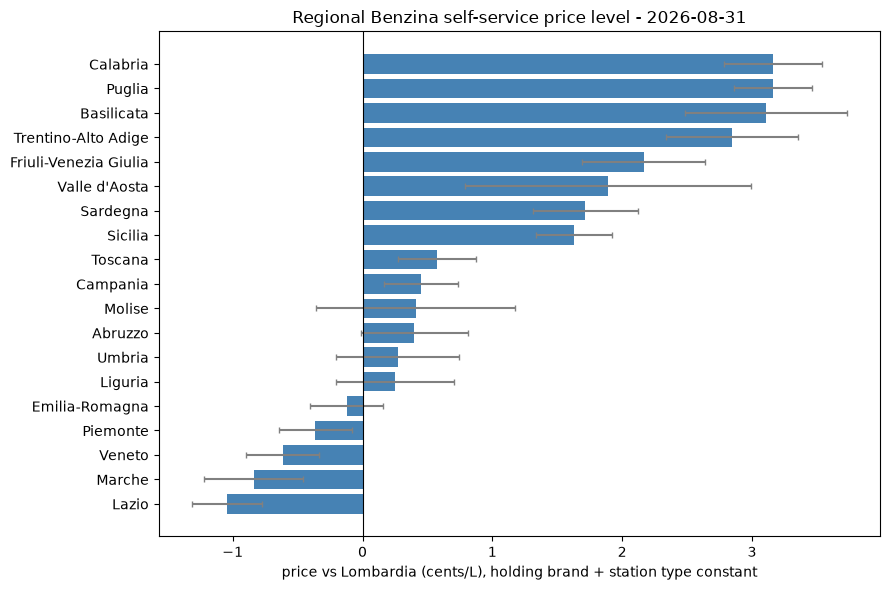

Lazio                   -1.04
Marche                  -0.84
Veneto                  -0.62
Piemonte                -0.36
Emilia-Romagna          -0.12
Liguria                  0.25
Umbria                   0.27
Abruzzo                  0.40
Molise                   0.41
Campania                 0.45
Toscana                  0.57
Sicilia                  1.63
Sardegna                 1.72
Valle d'Aosta            1.89
Friuli-Venezia Giulia    2.16
Trentino-Alto Adige      2.85
Basilicata               3.11
Puglia                   3.16
Calabria                 3.16
dtype: float64

In [5]:
# M2 region effects, in cents/L relative to Lombardia
region_effect = (m2.params[[i for i in m2.params.index if i.startswith('C(region)')]] * 100)
region_effect.index = [i.split('[T.')[1].rstrip(']') for i in region_effect.index]
region_effect = region_effect.sort_values()

ci = m2.conf_int().loc[[f'C(region)[T.{r}]' for r in region_effect.index]] * 100

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(region_effect.index, region_effect.values, color='steelblue')
ax.errorbar(region_effect.values, range(len(region_effect)),
            xerr=[region_effect.values - ci[0].values, ci[1].values - region_effect.values],
            fmt='none', ecolor='grey', capsize=2)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('price vs Lombardia (cents/L), holding brand + station type constant')
ax.set_title(f'Regional Benzina self-service price level - {SNAPSHOT_DATE}')
plt.tight_layout()
plt.show()

region_effect.round(2)

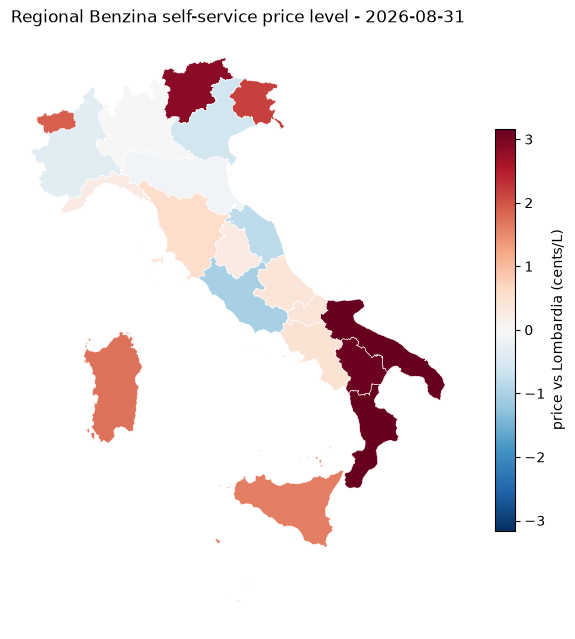

In [6]:
regions_gj = load_geojson('regions')

# same M2 effects as the bar chart, plus the reference region at 0
reg_values = {**region_effect.to_dict(), 'Lombardia': 0.0}
lim = max(abs(v) for v in reg_values.values())
norm = TwoSlopeNorm(vcenter=0.0, vmin=-lim, vmax=lim)
cmap = colormaps['RdBu_r']

fig, ax = plt.subplots(figsize=(6, 7))
choropleth(ax, regions_gj['features'], 'reg_name', reg_values, cmap, norm,
           key_fix=lambda s: s.split('/')[0])   # "Valle d'Aosta/Vallée d'Aoste" -> "Valle d'Aosta"
fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.6,
             label='price vs Lombardia (cents/L)')
ax.set_title(f'Regional Benzina self-service price level - {SNAPSHOT_DATE}')
plt.tight_layout()
plt.show()

The same effects on the map: pale-to-blue across the north-western and central
regions, deepening red down the peninsula and out to the islands, with a second
red pocket in the alpine north-east (Trentino-Alto Adige, Friuli). The gradient
is smooth and contiguous - it isn't one or two outlier regions dragging a spread,
it's a genuine north/centre vs south/periphery structure.

**M2 / M3.** Region matters and refinery distance does not:

- Adding the region fixed effect lifts R^2 from ~0.10 to ~0.16; adding refinery
  distance *on top* of region (M3) moves it by ~0.001 and leaves a coefficient
  near zero. Whatever "near a refinery" might do to price is already inside the
  regional differences - and mostly isn't there at all.
- The regional spread is about **4 cents/L**. Cheapest: the north-western
  industrial belt (Lombardia, Piemonte) plus Lazio, Marche and Veneto. Most
  expensive: **Calabria, Puglia and Basilicata (~+3 cents)**, then the
  mountainous/peripheral regions - Trentino-Alto Adige, Friuli, Valle d'Aosta -
  and the two islands. The usual explanations are competition density, haulage
  cost and thin southern retail markets (competition is tested directly further
  down - real, but only a secondary factor). It is not a refinery story: Sicily
  has three refineries and is still among the dearest.

## Cheapest / priciest areas nationally

Raw comune means confuse "genuinely cheap area" with "area full of discount
independents", so control for brand mix and station type
(`price ~ brand + station_type`, no geography) and average the residual by
province and by comune. That's how cheap or dear a place is *nationally*, once
its retail composition is accounted for - not "cheap for its own region" as in
the section above. Restricted to places with enough sampled stations.

In [7]:
m_bt = smf.ols('price ~ C(station_type) + C(brand_group)', data=df).fit()
df['resid'] = m_bt.resid * 100  # cents/L vs the national brand + type expectation


def residual_ranking(col, min_n):
    g = df.groupby(col)['resid'].agg(['mean', 'count'])
    return g[g['count'] >= min_n].sort_values('mean').round(2)


prov_rank = residual_ranking('province_code', 20)
print('Cheapest provinces (cents/L below the national brand + type expectation):')
print(prov_rank.head(8), '\n')
print('Priciest provinces:')
print(prov_rank.tail(8))

comune_rank = residual_ranking('comune', 8)
print('\nCheapest comuni:')
print(comune_rank.head(10), '\n')
print('Priciest comuni:')
print(comune_rank.tail(10))

Cheapest provinces (cents/L below the national brand + type expectation):
               mean  count
province_code             
RO            -3.87    124
BI            -3.35     69
AT            -3.23    112
FR            -2.78    247
VT            -2.60    151
CA            -1.97    129
VC            -1.85     80
MC            -1.62    152 

Priciest provinces:
               mean  count
province_code             
VV             2.72     54
RC             2.94    185
LE             3.38    382
MT             3.56     70
BZ             4.05    153
NU             4.16     85
KR             4.47     45
TS             4.65     32

Cheapest comuni:
                     mean  count
comune                          
CECCANO             -7.97      9
VITERBO             -7.73     38
SALÒ                -7.12      8
SORA                -6.80     18
PIOSSASCO           -6.54      8
ARGENTA             -6.36      8
BIELLA              -5.07     20
VILLARICCA          -5.07      8
CASTELFRANCO VEN

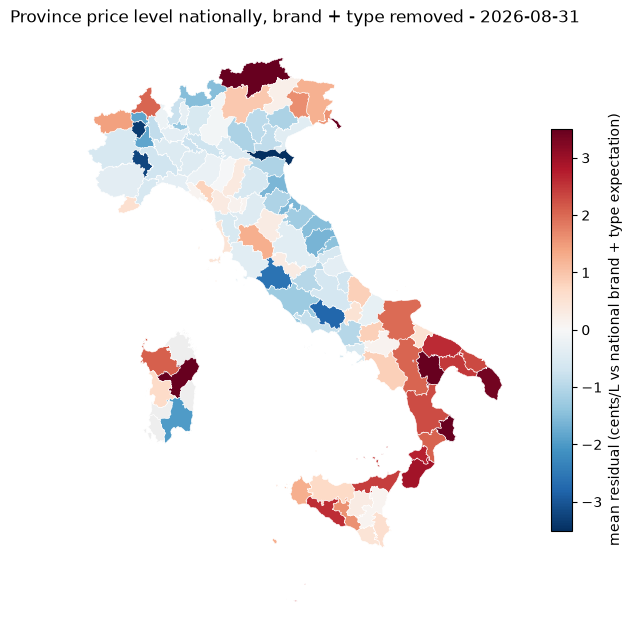

In [8]:
provinces_gj = load_geojson('provinces')

# province means are stable enough to map at any n, so use all provinces here
# (the table above keeps the >= 20 filter)
prov_resid = df.groupby('province_code')['resid'].mean()
lim = prov_resid.abs().quantile(0.95)
norm = TwoSlopeNorm(vcenter=0.0, vmin=-lim, vmax=lim)
cmap = colormaps['RdBu_r']

fig, ax = plt.subplots(figsize=(6, 7))
choropleth(ax, provinces_gj['features'], 'prov_acr', prov_resid.to_dict(), cmap, norm)
fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.6,
             label='mean residual (cents/L vs national brand + type expectation)')
ax.set_title(f'Province price level nationally, brand + type removed - {SNAPSHOT_DATE}')
plt.tight_layout()
plt.show()

Now the ranking is national: dark blue provinces are the cheapest in the country
once brand and station-type mix is removed, dark red the dearest - a spread of
about 8 cents/L, wider than the regional one. It broadly follows the regional
gradient (dearest across the deep south - Calabria, the Salento, Basilicata -
the alpine/border north-east of Trieste and Bolzano, and interior Sardinia) but
with sharp local detail on top: a cheap Piedmont cluster (Biella, Asti,
Vercelli), Rovigo, and southern Lazio around Frosinone and Viterbo sit well below
their neighbours.

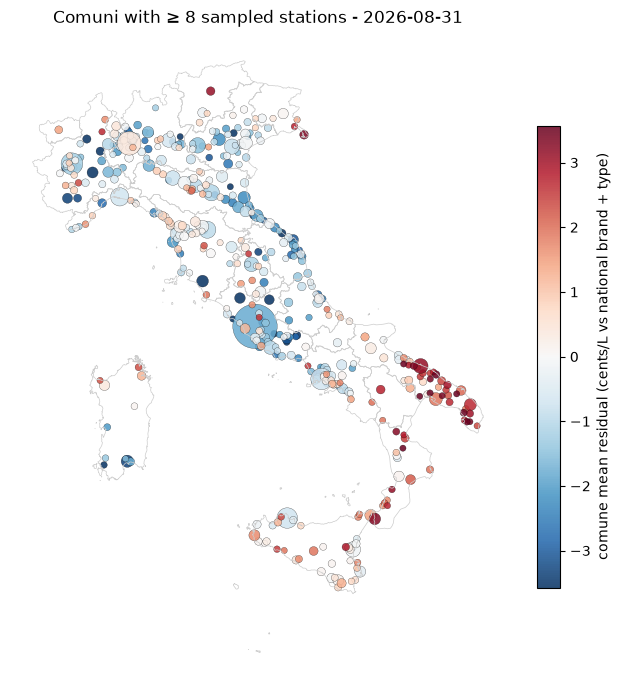

In [9]:
# Comune-level residuals on the map. Only ~300 of ~7,900 comuni have >= 8 sampled
# stations, so a filled municipal choropleth would be mostly blank - instead plot
# each qualifying comune at its stations' mean location, coloured by residual and
# sized by station count, over faint region outlines.
regions_gj = load_geojson('regions')
centroids = df.groupby('comune')[['longitude', 'latitude']].mean()
bubbles = comune_rank.join(centroids)

lim = bubbles['mean'].abs().quantile(0.95)

fig, ax = plt.subplots(figsize=(6.5, 8))
region_outlines(ax, regions_gj['features'])
sc = ax.scatter(bubbles['longitude'], bubbles['latitude'],
                c=bubbles['mean'], cmap='RdBu_r', vmin=-lim, vmax=lim,
                s=10 + bubbles['count'] * 1.3, edgecolor='k', linewidth=0.2, alpha=0.85)
ax.set_aspect(1 / np.cos(np.radians(42)))
ax.set_axis_off()
fig.colorbar(sc, ax=ax, shrink=0.6, label='comune mean residual (cents/L vs national brand + type)')
ax.set_title(f'Comuni with ≥ 8 sampled stations - {SNAPSHOT_DATE}')
plt.tight_layout()
plt.show()

The comuni echo it: the cheapest (Ceccano and Sora near Frosinone, Viterbo, Salò
on Lake Garda, Piossasco and Biella in Piedmont) show up as the same blue
pockets, while the priciest are almost all in Puglia's Salento and Ionian arc
(Casarano, Mesagne, Massafra, Ugento) with a scattering in Calabria. At this
level local competition and the regional gradient reinforce each other rather
than cancelling out.

## Is it competition?

The sections above kept calling the gradient a "competition and haulage" story
without testing it. Direct check: for every station, count how many other
stations sit within a 10 km drive (a rough catchment) against the full active
population, and add that to the brand + station-type model.

In [10]:
def local_competitors(lat, lon, ref_lat, ref_lon, radius_km, chunk=1000):
    """Count reference points within `radius_km` great-circle of each (lat, lon),
    chunked so the full pairwise matrix never materialises."""
    earth_km = 6371.0

    def unit_xyz(a, o):
        a, o = np.radians(np.asarray(a, float)), np.radians(np.asarray(o, float))
        return np.column_stack([np.cos(a) * np.cos(o), np.cos(a) * np.sin(o), np.sin(a)])

    pts, ref = unit_xyz(lat, lon), unit_xyz(ref_lat, ref_lon)
    max_chord2 = 2 - 2 * np.cos(radius_km / earth_km)
    out = np.empty(len(pts), dtype=int)
    for i in range(0, len(pts), chunk):
        chord2 = 2 - 2 * (pts[i:i + chunk] @ ref.T)
        out[i:i + chunk] = (chord2 <= max_chord2).sum(axis=1)
    return out


active = con.execute("""
    SELECT latitude, longitude FROM station
    WHERE latitude IS NOT NULL AND extraction_date >= DATE '2026-08-01'
""").df()

df['competitors_10km'] = np.maximum(
    local_competitors(df['latitude'], df['longitude'],
                      active['latitude'], active['longitude'], 10) - 1, 0)   # minus self

for label, formula in [
    ('brand + type', 'price ~ C(station_type) + C(brand_group) + np.log1p(competitors_10km)'),
    ('brand + type + region', 'price ~ C(station_type) + C(brand_group) + C(region) + np.log1p(competitors_10km)'),
]:
    fit = smf.ols(formula, data=df).fit()
    coef = fit.params['np.log1p(competitors_10km)'] * 100
    print(f"log(1 + competitors within 10 km), controlling for {label:<21}: "
          f"{coef:+.2f} cents/L   (p = {fit.pvalues['np.log1p(competitors_10km)']:.0e}, R^2 {fit.rsquared:.3f})")

decile = df.assign(bucket=pd.qcut(df['competitors_10km'], 10, labels=False, duplicates='drop'))
print()
print(decile.groupby('bucket').agg(
    competitors=('competitors_10km', 'median'),
    price_vs_brand_type=('resid', 'mean'),
    n=('price', 'size')).round(2))

log(1 + competitors within 10 km), controlling for brand + type         : -0.90 cents/L   (p = 9e-205, R^2 0.145)


log(1 + competitors within 10 km), controlling for brand + type + region: -0.72 cents/L   (p = 1e-109, R^2 0.188)

        competitors  price_vs_brand_type     n
bucket                                        
0               6.0                 2.74  2090
1              15.0                 0.50  2001
2              22.0                 0.32  2180
3              30.0                -0.04  1926
4              39.0                -0.27  2025
5              51.0                -0.73  2047
6              64.0                -0.28  1975
7              91.0                -0.42  1968
8             146.0                -0.81  2034
9             344.5                -1.13  2018


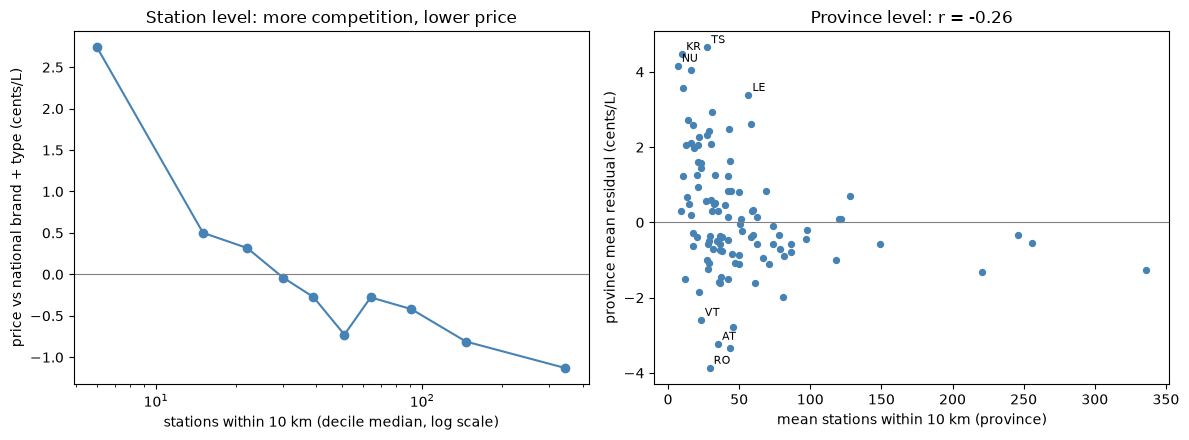

In [11]:
buckets = decile.groupby('bucket').agg(comp=('competitors_10km', 'median'),
                                       resid=('resid', 'mean'))
prov_comp = (df.groupby('province_code')
               .agg(resid=('resid', 'mean'), competitors=('competitors_10km', 'mean'),
                    n=('price', 'size'))
               .query('n >= 20'))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(buckets['comp'], buckets['resid'], 'o-', color='steelblue')
ax1.axhline(0, color='grey', linewidth=0.8)
ax1.set_xscale('log')
ax1.set_xlabel('stations within 10 km (decile median, log scale)')
ax1.set_ylabel('price vs national brand + type (cents/L)')
ax1.set_title('Station level: more competition, lower price')

ax2.scatter(prov_comp['competitors'], prov_comp['resid'], s=18, color='steelblue')
ax2.axhline(0, color='grey', linewidth=0.8)
for code in ['VT', 'RO', 'AT', 'TS', 'LE', 'NU', 'KR']:
    if code in prov_comp.index:
        r = prov_comp.loc[code]
        ax2.annotate(code, (r['competitors'], r['resid']), fontsize=8,
                     xytext=(3, 3), textcoords='offset points')
ax2.set_xlabel('mean stations within 10 km (province)')
ax2.set_ylabel('province mean residual (cents/L)')
ax2.set_title(f'Province level: r = {prov_comp["resid"].corr(prov_comp["competitors"]):+.2f}')

plt.tight_layout()
plt.show()

So the thesis holds, with limits:

- **More stations within reach does mean a lower price, robustly.** The
  coefficient is about -0.7 to -0.9 cents/L per unit of `log(competitors)` and
  survives the region control at p far below `1e-100`; almost every density
  decile prices below the last.
- **But it's front-loaded and modest.** An isolated station (a handful of
  neighbours) prices ~3 cents above the national norm; most of that closes by
  the time there are ~15-20 competitors, then the curve flattens. Adding local
  density to the model lifts R^2 by only ~0.02 once region is in.
- **At province level the link is weak** (r ≈ -0.3). The cheapest provinces
  (Viterbo, Rovigo, Asti) are only middling in local density, not standouts, and
  the dearest span the whole range - Lecce sits above the median for local
  competition and is still near the top for price. Between provinces the macro
  north-to-south gradient outweighs the local station count.

Competition is a real downward force on price, strongest at the "any rival at
all" margin, but it's a secondary driver - the bulk of the geographic spread is
the broad north-centre vs south/periphery gradient.

## Station 9233: CONAD, or more than that?

9233 is a CONAD forecourt in Casciana Terme Lari (province of Pisa, Toscana),
about 25 km from the Livorno refinery. CONAD is a supermarket chain, and
`02_price_drivers.ipynb` shows the supermarket brands undercut everyone else by
~4 cents/L - an effect the models' brand term here already carries. Compare
9233's actual price to what M2 (brand + type + region) and M3 (+ refinery
distance) predict for a station with its exact attributes: a residual near zero
means CONAD plus location fully explain it, a still-negative one means 9233 is
cheap even by CONAD standards - something station-specific this dataset can't
pin down.

In [12]:
mine = con.execute('''
    SELECT s.station_id, s.brand_name, s.station_type, s.comune, s.province_code,
           s.latitude, s.longitude, pc.price::double AS price
    FROM station s
    JOIN price_change pc ON pc.station_id = s.station_id
        AND pc.fuel_description = 'Benzina' AND pc.self_service = true
        AND pc.min_extraction_date <= ? AND pc.max_extraction_date >= ?
    WHERE s.station_id = 9233
''', [SNAPSHOT_DATE, SNAPSHOT_DATE]).df()

mine['region'] = mine['province_code'].map(PROVINCE_TO_REGION)
mine['dist_refinery_100km'] = np.min(
    [haversine_km(mine['latitude'], mine['longitude'], la, lo) for la, lo in _refs], axis=0) / 100
mine['brand_group'] = np.where(
    mine['brand_name'].isin(brand_counts[brand_counts >= 40].index), mine['brand_name'], 'Other')

print(mine[['brand_name', 'comune', 'region', 'dist_refinery_100km', 'price']].to_string(index=False))
print(f"\nregion effect for {mine['region'].iloc[0]}: "
      f"{region_effect.get(mine['region'].iloc[0], 0.0):+.2f} cents/L vs Lombardia")
for name, mdl in [('M2  (brand + type + region)', m2), ('M3  (+ refinery distance)', m3)]:
    pred = mdl.predict(mine).iloc[0]
    print(f"{name}: predicted {pred:.3f}  actual {mine['price'].iloc[0]:.3f}  "
          f"residual {mine['price'].iloc[0] - pred:+.3f}")

brand_name              comune  region  dist_refinery_100km  price
     CONAD CASCIANA TERME LARI Toscana             0.260818  1.949

region effect for Toscana: +0.57 cents/L vs Lombardia
M2  (brand + type + region): predicted 1.974  actual 1.949  residual -0.025
M3  (+ refinery distance): predicted 1.972  actual 1.949  residual -0.023


## Answers

1. **Not the refinery.** Distance to the nearest refinery doesn't predict price
   once region is accounted for (and barely does before). The first pass's
   "distance to Livorno" effect was a north-centre vs south/islands proxy.
2. **Yes, areas differ** - about 4 cents/L across regions net of brand and
   station type, and about 8 cents/L between the cheapest and dearest provinces
   nationally. **Competition density is part of it** - a station with more rivals
   within reach does price lower, robustly - **but only a secondary part**; most
   of the spread is the broad north-to-south gradient (supply logistics, thin
   southern markets). Cheapest in a few northern provinces (Rovigo, the
   Biella/Asti/Vercelli corner of Piedmont) and around Frosinone; dearest across
   the far south, interior Sardinia and the alpine north-east.
3. **9233 is mostly its brand.** CONAD is a supermarket chain, and the
   supermarket forecourts undercut everyone by ~4 cents/L
   (`02_price_drivers.ipynb`) - which the models' brand term carries. After
   brand + type + region it is still ~2.5 cents below prediction: cheap even for
   a CONAD, something station-specific this dataset can't pin down.